In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [27]:
df = pd.read_csv("../data/raw/BaseCLD2026.csv", sep=";", encoding="utf-8")

df.shape

(31126, 22)

In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31126 entries, 0 to 31125
Data columns (total 22 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   ID                     31126 non-null  int64  
 1   ANNEE                  31126 non-null  int64  
 2   COMMU_LAB              30828 non-null  object 
 3   RAIN                   31126 non-null  object 
 4   Sol_simple             31052 non-null  object 
 5   type_sol               28517 non-null  object 
 6   Date_prelevement       31126 non-null  object 
 7   Date_enregistrement    31126 non-null  object 
 8   Date_analyse           31126 non-null  object 
 9   Operateur_chld         31126 non-null  object 
 10  Taux_Chlordecone       31126 non-null  float64
 11  Operateur_5b           31126 non-null  object 
 12  Taux_5b_hydro          31114 non-null  object 
 13  histoBanane_Histo_ban  13143 non-null  float64
 14  mnt_tpi_mean           31098 non-null  float64
 15  mn

In [29]:
df.head()

,ID,ANNEE,COMMU_LAB,RAIN,Sol_simple,type_sol,Date_prelevement,Date_enregistrement,Date_analyse,Operateur_chld,...,Taux_5b_hydro,histoBanane_Histo_ban,mnt_tpi_mean,mnt_tri_mean,mnt_rugosite_mean,mnt_ombrage_mean,mnt_exposition_mean,mnt_pente_mean,X,Y
0,20143,2010,GROS-MORNE,2000-3000,Andosol,Intergrades Sols … allophane relativement ‚vol...,24/05/2007,24/05/2007,24/05/2007,=,...,"0,07",2.0,5.805967,8.033367,21.593658,131.173998,79.447954,39.043098,714300.831892,1.626344e+06
1,20143,2010,GROS-MORNE,2000-3000,Andosol,Intergrades Sols … allophane relativement ‚vol...,24/05/2007,24/05/2007,24/05/2007,=,...,"0,07",2.0,5.683589,7.920563,20.944901,134.608205,76.985690,38.123675,714303.743345,1.626354e+06
2,20143,2010,GROS-MORNE,2000-3000,Andosol,Intergrades Sols … allophane relativement ‚vol...,24/05/2007,24/05/2007,24/05/2007,=,...,"0,07",3.0,2.239457,7.108432,20.085883,139.420523,76.064719,34.976678,714309.446765,1.626360e+06
3,20143,2010,GROS-MORNE,2000-3000,Andosol,Intergrades Sols … allophane relativement ‚vol...,24/05/2007,24/05/2007,24/05/2007,=,...,"0,07",1.0,4.038373,7.530090,23.427731,121.603678,92.392454,38.315796,714294.208512,1.626321e+06
4,20143,2010,GROS-MORNE,2000-3000,Andosol,Intergrades Sols … allophane relativement ‚vol...,24/05/2007,24/05/2007,24/05/2007,=,...,"0,07",2.0,0.596502,6.637082,20.153770,134.065066,83.930611,33.877727,714303.823058,1.626341e+06


In [30]:
df.isna().sum().sort_values(ascending=False)

histoBanane_Histo_ban    17983
type_sol                  2609
COMMU_LAB                  298
Sol_simple                  74
mnt_pente_mean              28
mnt_exposition_mean         28
mnt_ombrage_mean            28
mnt_rugosite_mean           28
mnt_tri_mean                28
mnt_tpi_mean                28
Taux_5b_hydro               12
ID                           0
X                            0
Operateur_5b                 0
ANNEE                        0
Taux_Chlordecone             0
Operateur_chld               0
Date_analyse                 0
Date_enregistrement          0
Date_prelevement             0
RAIN                         0
Y                            0
dtype: int64

on gérera les NA plus tard 

## Conversion des décimales (virgules → float, objet → Numeric)

In [31]:
# Conversion des virgules en points
df["Taux_Chlordecone"] = (
    df["Taux_Chlordecone"]
    .astype(str)
    .str.replace(",", ".", regex=False)
)

# Conversion en float
df["Taux_Chlordecone"] = pd.to_numeric(
    df["Taux_Chlordecone"],
    errors="coerce"
)

# Vérification
print(df["Taux_Chlordecone"].dtype)




df["Taux_5b_hydro"] = (
    df["Taux_5b_hydro"]
    .astype(str)
    .str.replace(",", ".", regex=False)
)

df["Taux_5b_hydro"] = pd.to_numeric(
    df["Taux_5b_hydro"],
    errors="coerce"
)
print(df["Taux_5b_hydro"].dtype)

float64
float64


## Traitement des valeurs censurées (<)

### Operateur chld

In [32]:


# Indicateur de censure
df["chl_censure"] = (df["Operateur_chld"] == "<").astype(int)

# Remplacement standard LOD/2
df["Taux_Chlordecone_clean"] = np.where(
    df["Operateur_chld"] == "<",
    df["Taux_Chlordecone"] / 2,
    df["Taux_Chlordecone"]
)
# Vérification
df[["Operateur_chld", "Taux_Chlordecone", "Taux_Chlordecone_clean"]].head(25)

,Operateur_chld,Taux_Chlordecone,Taux_Chlordecone_clean
0,=,4.6000,4.60000
1,=,4.6000,4.60000
2,=,4.6000,4.60000
3,=,4.6000,4.60000
4,=,4.6000,4.60000
5,=,4.6000,4.60000
6,=,4.6000,4.60000
7,<,0.0033,0.00165
8,<,0.0033,0.00165
9,<,0.0033,0.00165


### Operateur 5b

In [33]:
df["Taux_5b_hydro"].value_counts()

Taux_5b_hydro
0.0010    8444
0.0033    5867
0.0150    5375
0.0100    3433
0.0000    1336
          ... 
0.0590       1
0.0530       1
0.0320       1
0.0318       1
0.0760       1
Name: count, Length: 154, dtype: int64

In [34]:
LOD = df.loc[
    (df["Operateur_5b"] == "<") & (~np.isinf(df["Taux_5b_hydro"])),
    "Taux_5b_hydro"
].max()
LOQ_high = df.loc[
    ~np.isinf(df["Taux_5b_hydro"]),
    "Taux_5b_hydro"
].max()
df["Taux_5b_hydro_clean"] = df.apply(
    lambda row:
        LOD/2 if row["Operateur_5b"] == "<"
        else LOQ_high if np.isinf(row["Taux_5b_hydro"])
        else row["Taux_5b_hydro"],
    axis=1
)
df[["Operateur_5b", "Taux_5b_hydro", "Taux_5b_hydro_clean"]].head(25)

,Operateur_5b,Taux_5b_hydro,Taux_5b_hydro_clean
0,=,0.070,0.070
1,=,0.070,0.070
2,=,0.070,0.070
3,=,0.070,0.070
4,=,0.070,0.070
5,=,0.070,0.070
6,=,0.070,0.070
7,<,inf,499.500
8,=,0.015,0.015
9,=,0.015,0.015


Les valeurs inf représentent des mesures au‑delà de la limite maximale détectable, ce qui correspond à une censure à droite.

On calcule alors une borne haute (LOQ_high) en prenant la plus grande valeur réelle non infinie du jeu de données.

Les inf sont ensuite remplacés par cette borne haute, tandis que les valeurs < sont remplacées par LOD/2, ce qui donne une variable propre et utilisable pour l’analyse.

Les observations pour lesquelles l’opérateur analytique est “<” correspondent à des concentrations inférieures à la limite de détection (LOD). La valeur exacte étant inconnue mais comprise entre 0 et la LOD, une substitution par LOD/2 a été appliquée. Cette méthode, couramment utilisée en sciences environnementales, permet de limiter les biais liés à la censure des données tout en conservant l’ensemble des observations pour l’analyse statistique.

## Convertir les dates correctement

In [35]:
date_cols = ["Date_prelevement", "Date_enregistrement", "Date_analyse"]

for c in date_cols:
    df[c] = pd.to_datetime(df[c], dayfirst=True, errors="coerce")

df[date_cols].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31126 entries, 0 to 31125
Data columns (total 3 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   Date_prelevement     31126 non-null  datetime64[ns]
 1   Date_enregistrement  31126 non-null  datetime64[ns]
 2   Date_analyse         28424 non-null  datetime64[ns]
dtypes: datetime64[ns](3)
memory usage: 729.6 KB


# Etudes des NA

In [36]:
A=df.isnull().sum()
B=A/len(df)*100
missing_data = pd.DataFrame({"count": A, "percent": B}).sort_values(by="percent", ascending=False)
print(missing_data)

                        count    percent
histoBanane_Histo_ban   17983  57.774851
Date_analyse             2702   8.680846
type_sol                 2609   8.382060
COMMU_LAB                 298   0.957399
Sol_simple                 74   0.237743
mnt_pente_mean             28   0.089957
mnt_exposition_mean        28   0.089957
mnt_ombrage_mean           28   0.089957
mnt_rugosite_mean          28   0.089957
mnt_tri_mean               28   0.089957
mnt_tpi_mean               28   0.089957
Taux_5b_hydro              23   0.073893
Taux_5b_hydro_clean        12   0.038553
ANNEE                       0   0.000000
Operateur_5b                0   0.000000
Taux_Chlordecone            0   0.000000
Operateur_chld              0   0.000000
Date_enregistrement         0   0.000000
Date_prelevement            0   0.000000
RAIN                        0   0.000000
X                           0   0.000000
Y                           0   0.000000
chl_censure                 0   0.000000
Taux_Chlordecone

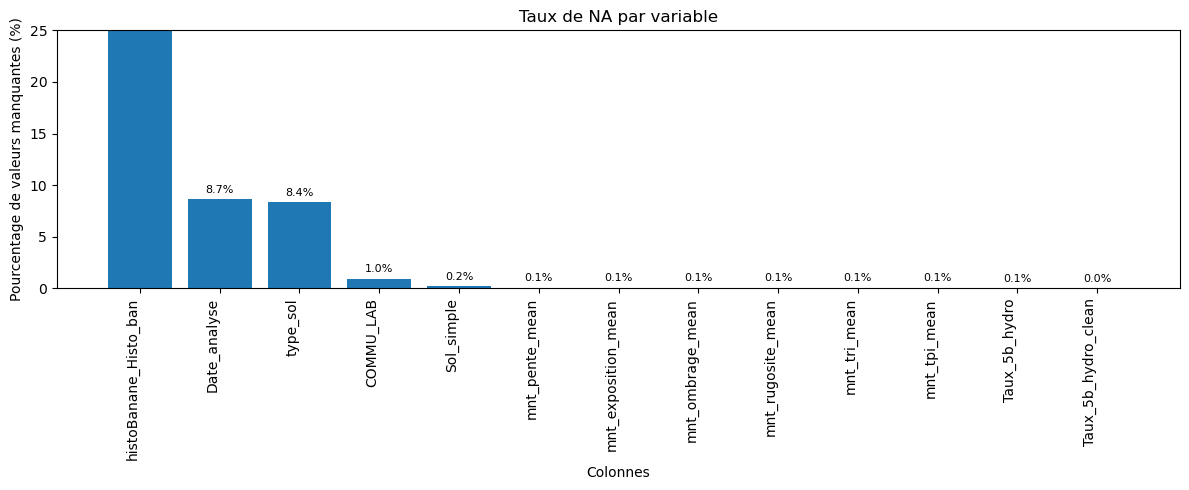

In [37]:
missing_data = pd.DataFrame({
    "count": df.isnull().sum(),
    "percent": df.isnull().mean() * 100
}).sort_values(by="percent", ascending=False)

missing_data = missing_data[missing_data["percent"] > 0]  # optionnel

plt.figure(figsize=(12, 5))
bars = plt.bar(missing_data.index, missing_data["percent"], color="tab:blue")
plt.ylim(0, 25)  # ou autre limite (ou suppression si pas besoin)
plt.xticks(rotation=90, ha="right")
plt.xlabel("Colonnes")
plt.ylabel("Pourcentage de valeurs manquantes (%)")
plt.title("Taux de NA par variable")

for bar in bars:
    height = bar.get_height()
    plt.annotate(
        f"{height:.1f}%",
        xy=(bar.get_x() + bar.get_width() / 2, height),
        xytext=(0, 3),
        textcoords="offset points",
        ha="center",
        va="bottom",
        fontsize=8
    )

plt.tight_layout()
plt.show()

Nous avons beaucoup de variables qui ont des données manquantes, nous allons les traiter cas par cas

### Analyse de histoBanane_Histo_ban

In [38]:
df["histoBanane_Histo_ban"].describe()

count    13143.000000
mean         1.673286
std          0.732067
min          1.000000
25%          1.000000
50%          2.000000
75%          2.000000
max          3.000000
Name: histoBanane_Histo_ban, dtype: float64

In [39]:
df["histoBanane_Histo_ban"] = df["histoBanane_Histo_ban"].astype("Int64")

df["histoBanane_cat"] = df["histoBanane_Histo_ban"].astype("string")
df["histoBanane_cat"] = df["histoBanane_cat"].fillna("Inconnu")

df["histoBanane_cat"].value_counts()

histoBanane_cat
Inconnu    17983
1           6370
2           4697
3           2076
Name: count, dtype: Int64

La variable histoBanane_Histo_ban prend des valeurs discrètes comprises entre 1 et 3, ce qui suggère qu’il s’agit d’une variable catégorielle ordinale représentant le niveau d’historique de culture bananière sur la parcelle. Cependant, plus de 57 % des observations présentent une valeur manquante. Plutôt que de supprimer ces données ou d’imputer arbitrairement une valeur, la variable a été convertie en catégorie et une modalité supplémentaire "Inconnu" a été créée pour conserver l’information liée à l’absence de renseignement. Cette approche permet d’éviter une perte d’information tout en maintenant la variable exploitable dans les analyses explicatives ultérieures.

type_sol et sol_simple

In [40]:
df["type_sol"] = df["type_sol"].fillna("Inconnu")
df['Sol_simple'] = df['Sol_simple'].fillna("Inconnu")

Label des communes

In [41]:
df["COMMU_LAB"] = df["COMMU_LAB"].fillna("inconnu")


Date_analyse (2702 NA)

In [42]:
df["Date_analyse"].isna().mean() # 

0.08680845595322238

La variable Date_analyse présente 8,7 % de valeurs manquantes. Ce niveau reste modéré et ne justifie pas la suppression des observations concernées. La variable est conservée pour l’analyse temporelle et le calcul du délai entre prélèvement et analyse. Les valeurs manquantes sont maintenues telles quelles et exclues uniquement des analyses nécessitant explicitement cette information.

Topographie : nous imputons toutes les NA dans les variables commençant par mnt_

In [43]:
topo_cols = [c for c in df.columns if c.startswith("mnt_")]
for c in topo_cols:
    df[c] = df[c].fillna(df[c].median())

In [44]:
# supprimer nan
df['Taux_5b_hydro_clean'] = df['Taux_5b_hydro_clean'].fillna(df['Taux_5b_hydro_clean'].median())

In [45]:
A=df.isnull().sum()
B=(A/len(df))*100
missing_data = pd.DataFrame({"count": A, "percent": B}).sort_values(by="percent", ascending=False)
print(missing_data)

                        count    percent
histoBanane_Histo_ban   17983  57.774851
Date_analyse             2702   8.680846
Taux_5b_hydro              23   0.073893
mnt_tpi_mean                0   0.000000
Taux_5b_hydro_clean         0   0.000000
Taux_Chlordecone_clean      0   0.000000
chl_censure                 0   0.000000
Y                           0   0.000000
X                           0   0.000000
mnt_pente_mean              0   0.000000
mnt_exposition_mean         0   0.000000
mnt_ombrage_mean            0   0.000000
mnt_rugosite_mean           0   0.000000
mnt_tri_mean                0   0.000000
ID                          0   0.000000
ANNEE                       0   0.000000
Operateur_5b                0   0.000000
Taux_Chlordecone            0   0.000000
Operateur_chld              0   0.000000
Date_enregistrement         0   0.000000
Date_prelevement            0   0.000000
type_sol                    0   0.000000
Sol_simple                  0   0.000000
RAIN            

In [46]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31126 entries, 0 to 31125
Data columns (total 26 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   ID                      31126 non-null  int64         
 1   ANNEE                   31126 non-null  int64         
 2   COMMU_LAB               31126 non-null  object        
 3   RAIN                    31126 non-null  object        
 4   Sol_simple              31126 non-null  object        
 5   type_sol                31126 non-null  object        
 6   Date_prelevement        31126 non-null  datetime64[ns]
 7   Date_enregistrement     31126 non-null  datetime64[ns]
 8   Date_analyse            28424 non-null  datetime64[ns]
 9   Operateur_chld          31126 non-null  object        
 10  Taux_Chlordecone        31126 non-null  float64       
 11  Operateur_5b            31126 non-null  object        
 12  Taux_5b_hydro           31103 non-null  float6

## Détection des outliers pour variables numériques

In [47]:

num_cols = df.select_dtypes(include=["float64", "int64"]).columns

outlier_summary = []

for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    upper = Q3 + 1.5 * IQR
    lower = Q1 - 1.5 * IQR
    
    n_out = df[(df[col] > upper) | (df[col] < lower)].shape[0]
    
    outlier_summary.append({
        "variable": col,
        "n_outliers": n_out,
        "percent_outliers": round(n_out / len(df) * 100, 2)
    })

outlier_df = pd.DataFrame(outlier_summary).sort_values("percent_outliers", ascending=False)

outlier_df

,variable,n_outliers,percent_outliers
2,Taux_Chlordecone,5446,17.50
13,Taux_Chlordecone_clean,5440,17.48
3,Taux_5b_hydro,4409,14.17
5,mnt_tpi_mean,2301,7.39
6,mnt_tri_mean,904,2.90
10,mnt_pente_mean,819,2.63
7,mnt_rugosite_mean,799,2.57
8,mnt_ombrage_mean,712,2.29
0,ID,0,0.00
1,ANNEE,0,0.00


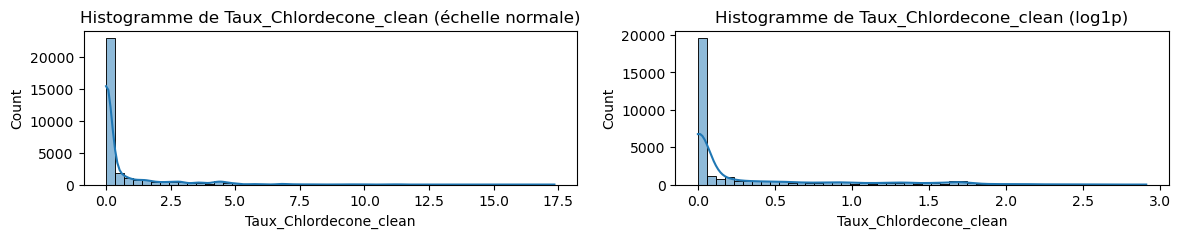

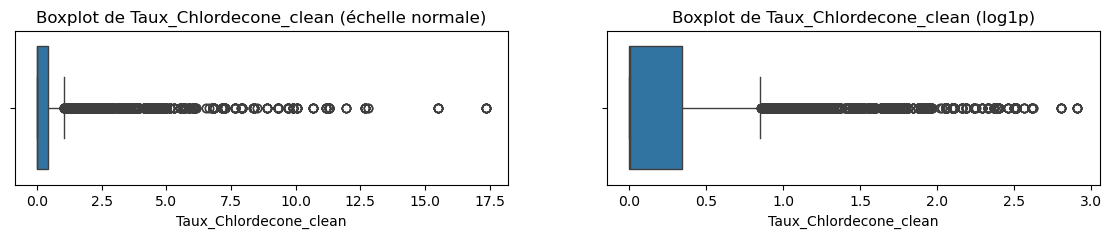

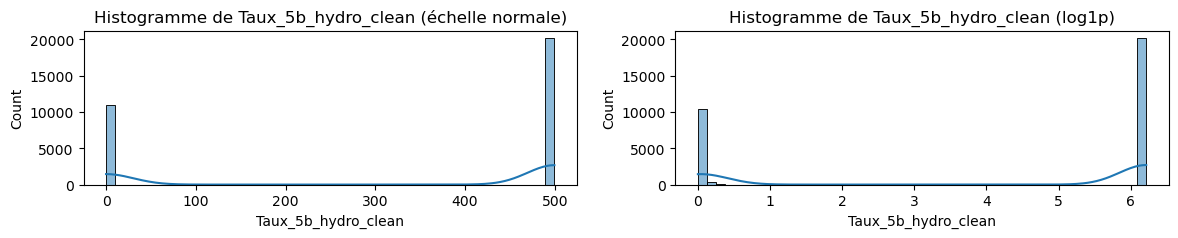

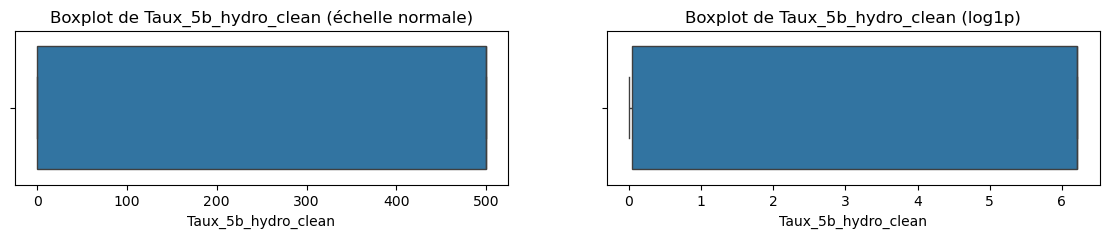

In [48]:
# Liste des variables à analyser
vars_to_plot = ["Taux_Chlordecone_clean", "Taux_5b_hydro_clean"]

for col in vars_to_plot:
    fig, axes = plt.subplots(1, 2, figsize=(14, 2))

    # Histogramme normal
    sns.histplot(df[col], bins=50, ax=axes[0], kde=True)
    axes[0].set_title(f"Histogramme de {col} (échelle normale)")

    # Histogramme log-scale
    sns.histplot(np.log1p(df[col]), bins=50, ax=axes[1], kde=True)
    axes[1].set_title(f"Histogramme de {col} (log1p)")

    plt.show()

    # Boxplots
    fig, axes = plt.subplots(1, 2, figsize=(14, 2))

    sns.boxplot(x=df[col], ax=axes[0])
    axes[0].set_title(f"Boxplot de {col} (échelle normale)")

    sns.boxplot(x=np.log1p(df[col]), ax=axes[1])
    axes[1].set_title(f"Boxplot de {col} (log1p)")

    plt.show()


Les distributions chimiques sont extrêmement asymétriques, avec une forte concentration de valeurs proches de zéro.

Les histogrammes en échelle normale écrasent l’information à cause des valeurs très élevées.

La transformation log1p rend la distribution lisible et met en évidence la structure réelle des données.

Les boxplots normaux montrent une multitude d’“outliers” qui sont en réalité des valeurs scientifiquement valides.

Les boxplots log‑scale révèlent une distribution cohérente et interprétable, sans masquer les extrêmes.

Conclusion : la transformation log est indispensable pour analyser correctement les concentrations chimiques et éviter de fausses interprétations.

#### La transformation log

In [49]:
# Création version log pour analyses futures
df["log_chl"] = np.log1p(df["Taux_Chlordecone_clean"])
df["log_5b"] = np.log1p(df["Taux_5b_hydro_clean"])

## Export du dataset propre

In [50]:
df.to_csv("../data/processed/BaseCLD2026_clean.csv", index=False)